In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
import os

load_dotenv()

True

In [26]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
GROQ_MODEL=os.getenv("GROQ_MODEL")

llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [27]:
class JokeState():
    topic: str
    joke: str
    explanation: str

In [28]:
def generate_joke(state: JokeState):
    topic = state["topic"]
    
    prompt = f"Generate the joke on this topic {topic}."
    
    response = llm.invoke(prompt).content
    
    return {"joke": response}

In [29]:
def explain_joke(state: JokeState):
    
    topic = state["topic"]
    joke = state["joke"]
    
    prompt = f"Explain the the joke on this topic {topic} and the actual joke is this:\n {joke}"
    
    response = llm.invoke(prompt).content
    
    return {"explanation": response}

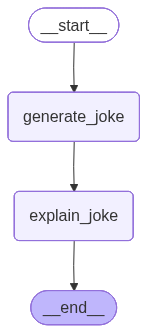

In [30]:
graph = StateGraph(JokeState)
graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkepointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkepointer)

workflow

In [31]:
thread_id = 1
config1 = {"configurable": {"thread_id": thread_id}}

initial_state = {"topic": "Pizza"}

final_state = workflow.invoke(initial_state, config=config1)

print(final_state)

{'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}


In [32]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ef6c-763f-6c4a-8002-f9822d471c95'}}, metadata={'source': 'loop', 'step':

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ef6c-763f-6c4a-8002-f9822d471c95'}}, metadata={'source': 'loop', 'step'

In [34]:
config2 = {"configurable": {"thread_id": "2"}}

result = workflow.invoke({"topic": "Pasta"}, config=config2)

In [35]:
print(result)

{'topic': 'Pasta', 'joke': 'Why did the pasta go to therapy?\n\nBecause it was feeling a little "drained" and wanted to work through some "saucy" issues.', 'explanation': 'A clever joke. Let\'s break it down:\n\nThe joke is a play on words, using puns related to pasta to create a humorous effect. Here\'s how it works:\n\n1. **"Drained"**: Pasta is typically drained of water after cooking, so the word "drained" has a literal meaning in the context of pasta. However, in this joke, "drained" also means emotionally exhausted or depleted, which is a common reason for seeking therapy.\n2. **"Saucy"**: Sauces are a common accompaniment to pasta dishes, so "saucy" is a word closely associated with pasta. In this joke, "saucy" also means provocative, flirtatious, or slightly scandalous, implying that the pasta has some juicy or problematic issues to work through.\n\nThe humor comes from the unexpected twist on the usual meanings of these words. The joke sets up a familiar situation (pasta being

In [36]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ef6c-763f-6c4a-8002-f9822d471c95'}}, metadata={'source': 'loop', 'step':

In [37]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Pasta', 'joke': 'Why did the pasta go to therapy?\n\nBecause it was feeling a little "drained" and wanted to work through some "saucy" issues.', 'explanation': 'A clever joke. Let\'s break it down:\n\nThe joke is a play on words, using puns related to pasta to create a humorous effect. Here\'s how it works:\n\n1. **"Drained"**: Pasta is typically drained of water after cooking, so the word "drained" has a literal meaning in the context of pasta. However, in this joke, "drained" also means emotionally exhausted or depleted, which is a common reason for seeking therapy.\n2. **"Saucy"**: Sauces are a common accompaniment to pasta dishes, so "saucy" is a word closely associated with pasta. In this joke, "saucy" also means provocative, flirtatious, or slightly scandalous, implying that the pasta has some juicy or problematic issues to work through.\n\nThe humor comes from the unexpected twist on the usual meanings of these words. The joke sets up a familiar s

### Time Travel

In [38]:
workflow.get_state({"configurable": {"thread_id": "1", "checkepoint_id": "1f16ef4f-9f0a-6335-8000-434790eeff49"}})

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ef6c-763f-6c4a-8002-f9822d471c95'}}, metadata={'source': 'loop', 'step':

In [39]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkepoint_id": "1f16ef4f-9f0a-6335-8000-434790eeff49"}})

{'topic': 'Pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}

In [40]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ef6c-763f-6c4a-8002-f9822d471c95'}}, metadata={'source': 'loop', 'step'

### Update State

In [44]:
workflow.update_state({"configurable": {"thread_id": "1", "checkepoint_id": "1f16ef6c-663f-6de6-8000-77c28ea21afa", "checkpoint_ns": ""}}, {"topic": "Fast Food"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16ef72-55dc-6e4b-8004-bea0c22c635b'}}

In [48]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Fast Food', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ef72-55dc-6e4b-8004-bea0c22c635b'}}, metadata={'source': 'update', 

In [50]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkepoint_id": "1f16ef6c-87a5-66ed-8003-909a1940b400"}})

{'topic': 'Fast Food',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A delicious joke. The joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling a little crusty" is also an idiomatic expression that means being in a bad mood or being irritable.\n\nSo, the joke is saying that the pizza is in a bad mood because it\'s "feeling a little crusty", which is a clever and humorous way to connect the pizza\'s physical characteristic (having a crust) to its emotional state (being in a bad mood). The wordplay creates a lighthearted and amusing effect, making it a fun and cheesy joke (pun intended).'}